**Import Libraries**

In [153]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler,MinMaxScaler,OneHotEncoder
sns.set()

In [154]:
data=pd.read_csv('Live_20210128.csv')
data.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


In [11]:
print(data.shape)

(7050, 16)


**Data preprocessing**

In [155]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   int64  
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(10), object(2)
memory

In [13]:
data.isna().sum()

,0
status_id,0
status_type,0
status_published,0
num_reactions,0
num_comments,0
num_shares,0
num_likes,0
num_loves,0
num_wows,0
num_hahas,0


In [156]:
data.drop(data[['status_id','status_published','Column1','Column2','Column3','Column4']],axis=1,inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   status_type    7050 non-null   object
 1   num_reactions  7050 non-null   int64 
 2   num_comments   7050 non-null   int64 
 3   num_shares     7050 non-null   int64 
 4   num_likes      7050 non-null   int64 
 5   num_loves      7050 non-null   int64 
 6   num_wows       7050 non-null   int64 
 7   num_hahas      7050 non-null   int64 
 8   num_sads       7050 non-null   int64 
 9   num_angrys     7050 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 550.9+ KB


In [157]:
enc=LabelEncoder()
data['status_type']=enc.fit_transform(data['status_type'])

In [158]:
dict(zip(enc.classes_, enc.transform(enc.classes_)))

{'link': np.int64(0),
 'photo': np.int64(1),
 'status': np.int64(2),
 'video': np.int64(3)}

In [159]:
data.describe().round(2)

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
count,7050.00,7050.00,7050.00,7050.00,7050.00,7050.00,7050.00,7050.00,7050.00,7050.00
mean,1.70,230.12,224.36,40.02,215.04,12.73,1.29,0.70,0.24,0.11
std,0.94,462.63,889.64,131.60,449.47,39.97,8.72,3.96,1.60,0.73
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,17.00,0.00,0.00,17.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,59.50,4.00,0.00,58.00,0.00,0.00,0.00,0.00,0.00
75%,3.00,219.00,23.00,4.00,184.75,3.00,0.00,0.00,0.00,0.00
max,3.00,4710.00,20990.00,3424.00,4710.00,657.00,278.00,157.00,51.00,31.00


/tmp/ipython-input-2515208891.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='status_type', palette="bright")


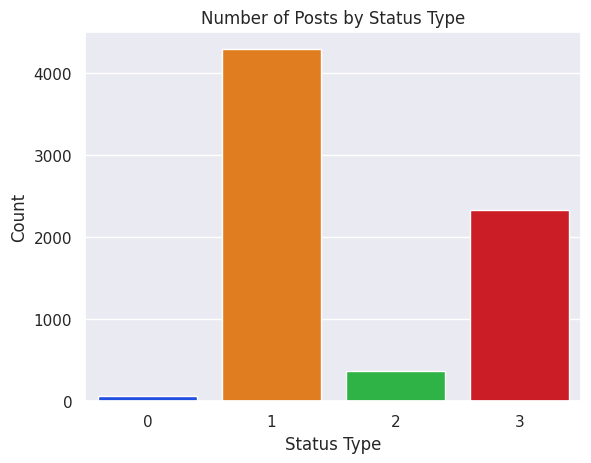

In [29]:
sns.countplot(data=data, x='status_type', palette="bright")
plt.title('Number of Posts by Status Type')
plt.xlabel('Status Type')
plt.ylabel('Count')
plt.show()


/tmp/ipython-input-3837100552.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='status_type',y='num_reactions', palette="bright")


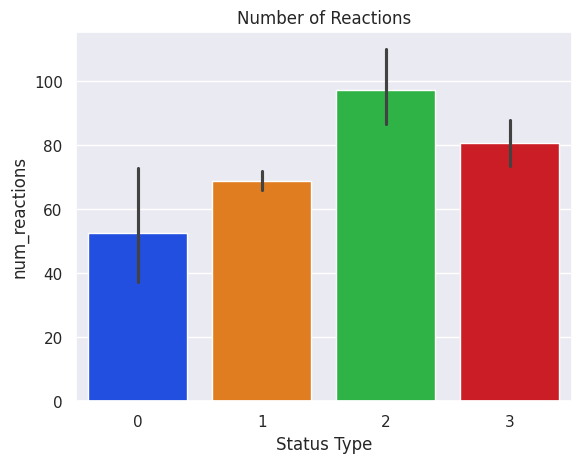

In [203]:
sns.barplot(data=data, x='status_type',y='num_reactions', palette="bright")
plt.title('Number of Reactions')
plt.xlabel('Status Type')
plt.ylabel('num_reactions')
plt.show()

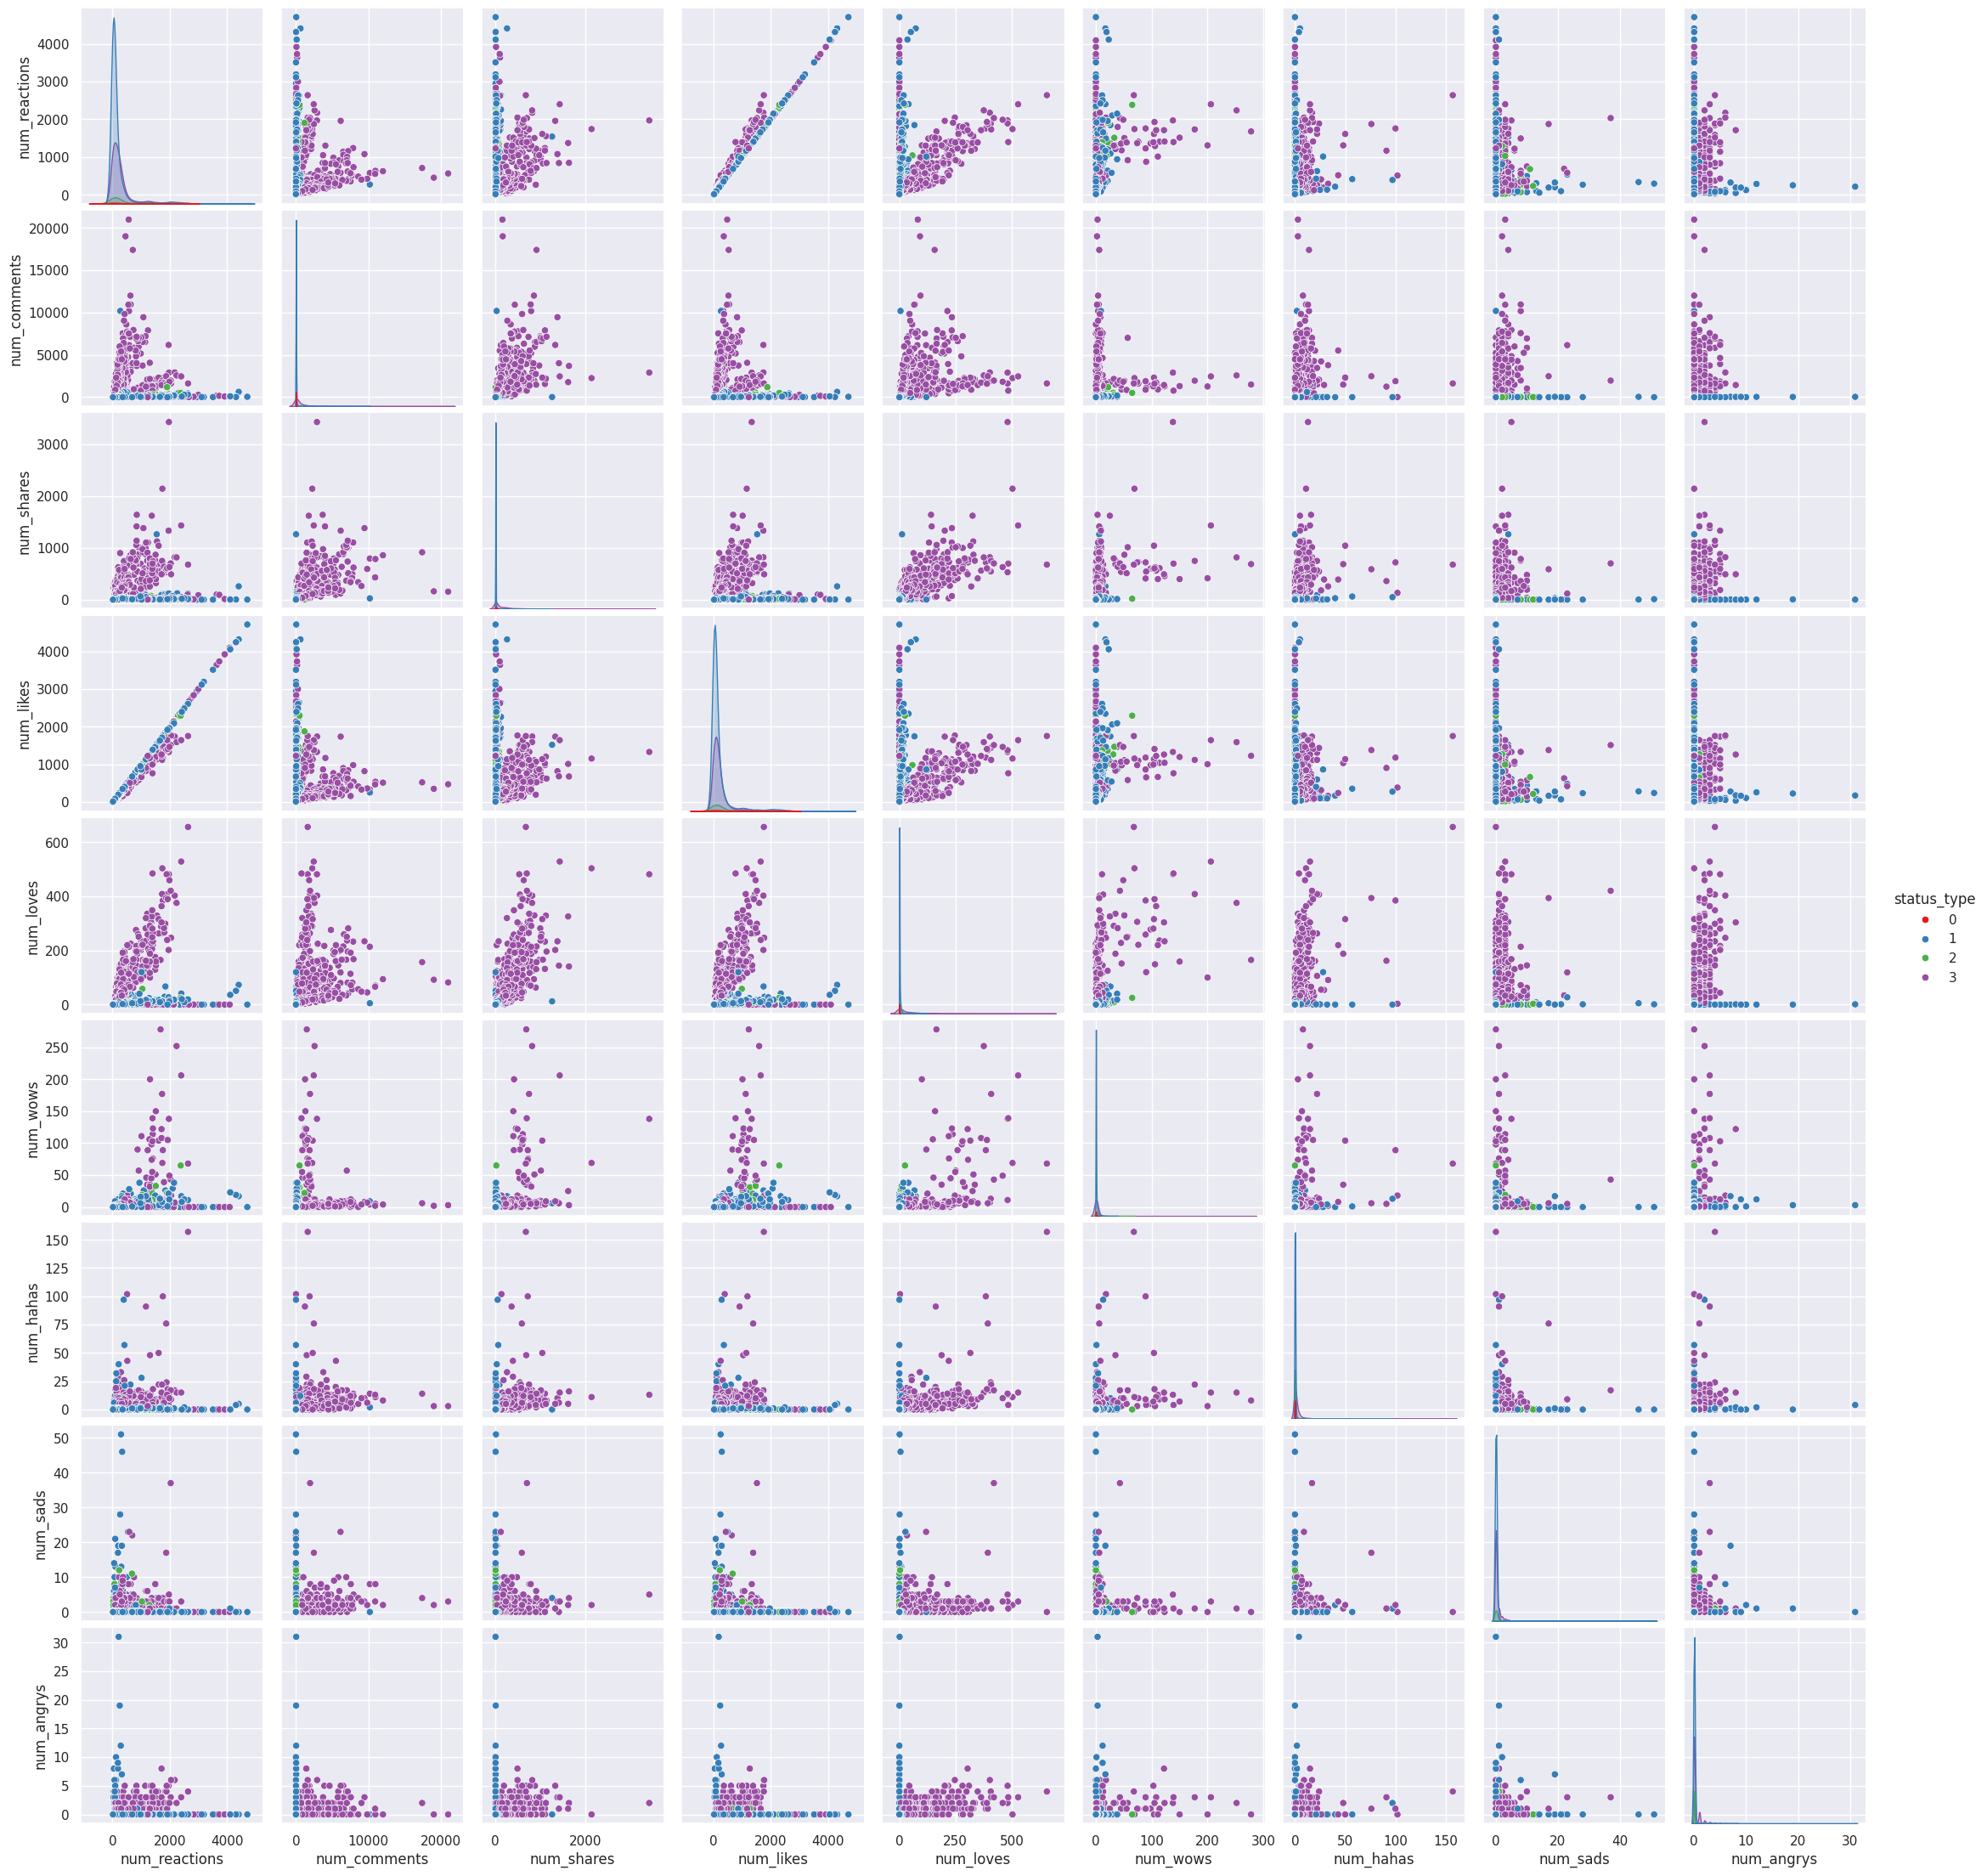

In [34]:
sns.pairplot(data,palette='Set1',hue='status_type')

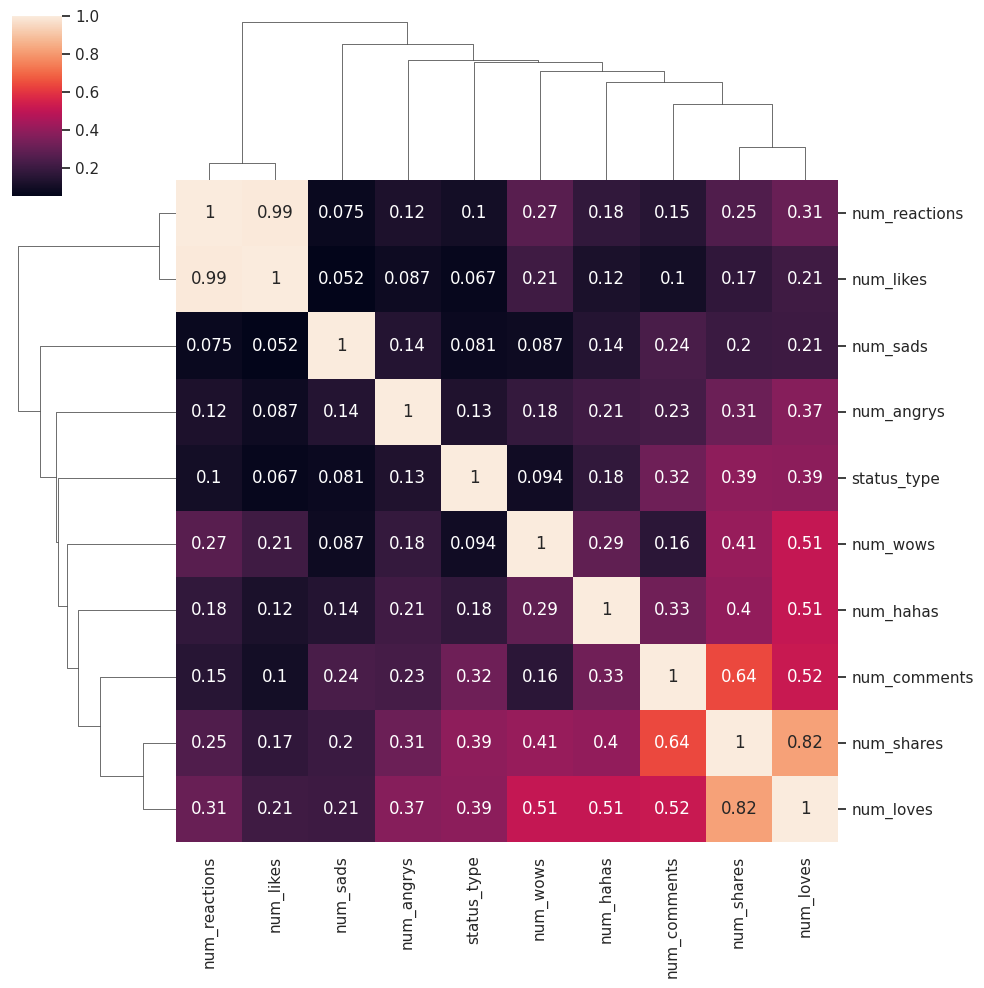

In [35]:
sns.clustermap(data.corr(),annot=True)

outliers

<Axes: >

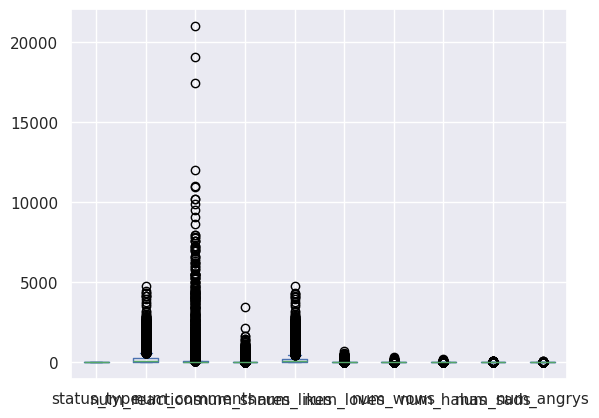

In [37]:
data.plot.box()

<Axes: >

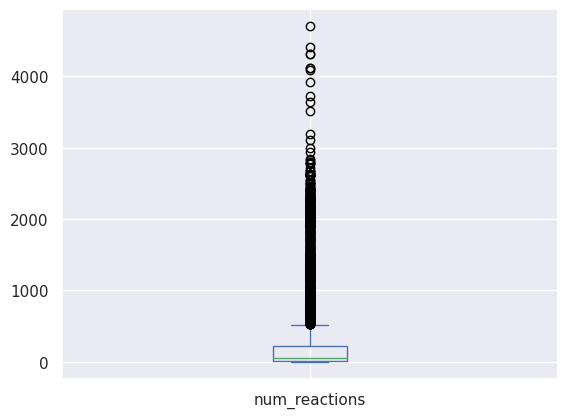

In [38]:
data['num_reactions'].plot.box()

In [160]:
q1 = data['num_reactions'].quantile(0.25)
q3 = data['num_reactions'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
data = data[(data['num_reactions'] >= lower) & (data['num_reactions'] <= upper)]


In [161]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6345 entries, 1 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   status_type    6345 non-null   int64
 1   num_reactions  6345 non-null   int64
 2   num_comments   6345 non-null   int64
 3   num_shares     6345 non-null   int64
 4   num_likes      6345 non-null   int64
 5   num_loves      6345 non-null   int64
 6   num_wows       6345 non-null   int64
 7   num_hahas      6345 non-null   int64
 8   num_sads       6345 non-null   int64
 9   num_angrys     6345 non-null   int64
dtypes: int64(10)
memory usage: 545.3 KB


In [162]:
q1 = data['num_comments'].quantile(0.25)
q3 = data['num_comments'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
data = data[(data['num_comments'] >= lower) & (data['num_comments'] <= upper)]


In [163]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5163 entries, 1 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   status_type    5163 non-null   int64
 1   num_reactions  5163 non-null   int64
 2   num_comments   5163 non-null   int64
 3   num_shares     5163 non-null   int64
 4   num_likes      5163 non-null   int64
 5   num_loves      5163 non-null   int64
 6   num_wows       5163 non-null   int64
 7   num_hahas      5163 non-null   int64
 8   num_sads       5163 non-null   int64
 9   num_angrys     5163 non-null   int64
dtypes: int64(10)
memory usage: 443.7 KB


In [164]:
data.describe().round(2)

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
count,5163.00,5163.00,5163.00,5163.00,5163.00,5163.00,5163.00,5163.00,5163.00,5163.00
mean,1.45,72.47,4.51,1.53,71.01,0.85,0.31,0.15,0.11,0.03
std,0.82,100.53,7.02,7.50,98.61,2.34,1.10,2.41,1.18,0.52
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,12.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,28.00,1.00,0.00,28.00,0.00,0.00,0.00,0.00,0.00
75%,2.00,86.00,6.00,1.00,83.00,1.00,0.00,0.00,0.00,0.00
max,3.00,520.00,40.00,227.00,519.00,42.00,21.00,102.00,51.00,19.00


In [43]:
q1 = data['num_shares'].quantile(0.25)
q3 = data['num_shares'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
data = data[(data['num_shares'] >= lower) & (data['num_shares'] <= upper)]

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4631 entries, 1 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   status_type    4631 non-null   int64
 1   num_reactions  4631 non-null   int64
 2   num_comments   4631 non-null   int64
 3   num_shares     4631 non-null   int64
 4   num_likes      4631 non-null   int64
 5   num_loves      4631 non-null   int64
 6   num_wows       4631 non-null   int64
 7   num_hahas      4631 non-null   int64
 8   num_sads       4631 non-null   int64
 9   num_angrys     4631 non-null   int64
dtypes: int64(10)
memory usage: 398.0 KB


In [46]:
data_cp=data.copy()

**Standerization**

In [47]:
scaler=StandardScaler()

In [70]:
x_scaled=scaler.fit_transform(data_cp)
x_scaled=pd.DataFrame(x_scaled, columns=data_cp.columns, index=data_cp.index)
x_scaled

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
1,-0.514634,0.921267,-0.634945,-0.471573,0.949634,-0.356663,-0.275502,-0.096654,-0.099157,-0.061336
3,-0.514634,0.503558,-0.634945,-0.471573,0.524836,-0.356663,-0.275502,-0.096654,-0.099157,-0.061336
4,-0.514634,1.596029,-0.634945,-0.471573,1.537817,3.970955,-0.275502,-0.096654,-0.099157,-0.061336
5,-0.514634,1.638871,0.285666,-0.471573,1.614063,2.047569,0.805725,-0.096654,-0.099157,-0.061336
8,-0.514634,1.488924,-0.481510,-0.471573,1.472464,2.047569,-0.275502,-0.096654,-0.099157,-0.061336
...,...,...,...,...,...,...,...,...,...,...
7044,-0.514634,0.235795,-0.634945,-0.471573,0.252529,-0.356663,-0.275502,-0.096654,-0.099157,-0.061336
7045,-0.514634,0.267927,-0.634945,-0.471573,0.285205,-0.356663,-0.275502,-0.096654,-0.099157,-0.061336
7046,-0.514634,-0.513940,-0.634945,-0.471573,-0.531715,0.124183,-0.275502,1.473896,-0.099157,-0.061336
7047,-0.514634,-0.663887,-0.634945,-0.471573,-0.673315,0.124183,-0.275502,-0.096654,-0.099157,-0.061336


In [49]:
sc = MinMaxScaler()
data_scaled=sc.fit_transform(data_cp)

In [50]:
data_scaled

array([[0.33333333, 0.28846154, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.33333333, 0.21346154, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.33333333, 0.40961538, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.33333333, 0.03076923, 0.        , ..., 0.04      , 0.        ,
        0.        ],
       [0.33333333, 0.00384615, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.33333333, 0.03269231, 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [52]:
data_scaled_df = pd.DataFrame(data_scaled, columns=data_cp.columns, index=data_cp.index)
data_scaled_df

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
1,0.333333,0.288462,0.000,0.0,0.291829,0.000000,0.000000,0.00,0.0,0.0
3,0.333333,0.213462,0.000,0.0,0.215953,0.000000,0.000000,0.00,0.0,0.0
4,0.333333,0.409615,0.000,0.0,0.396887,0.346154,0.000000,0.00,0.0,0.0
5,0.333333,0.417308,0.150,0.0,0.410506,0.192308,0.083333,0.00,0.0,0.0
8,0.333333,0.390385,0.025,0.0,0.385214,0.192308,0.000000,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
7044,0.333333,0.165385,0.000,0.0,0.167315,0.000000,0.000000,0.00,0.0,0.0
7045,0.333333,0.171154,0.000,0.0,0.173152,0.000000,0.000000,0.00,0.0,0.0
7046,0.333333,0.030769,0.000,0.0,0.027237,0.038462,0.000000,0.04,0.0,0.0
7047,0.333333,0.003846,0.000,0.0,0.001946,0.038462,0.000000,0.00,0.0,0.0


In [54]:
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

In [297]:
model_db = DBSCAN(eps=2)
model_KM=KMeans(n_clusters =4)

In [298]:
y_pred_db=model_db.fit_predict(x_scaled)
y_pred_KM=model_KM.fit_predict(x_scaled)



In [227]:
wcss =[]

# Create all possible cluster solutions with a loop
# We have chosen to get solutions from 1 to 9 clusters; you can ammend that if you wish
for i in range(1,10):
    # Clsuter solution with i clusters
    kmeans = KMeans(i)
    # Fit the STANDARDIZED data
    kmeans.fit(data_cp)
    # Append the WCSS for the iteration
    wcss.append(kmeans.inertia_)

# Check the result
wcss

[79634044.80457798,
 20552810.880129654,
 9540095.489979465,
 5456858.224829541,
 3692799.1130299154,
 2542164.9467254854,
 1948257.1494484465,
 1647967.5595252677,
 1299464.2185877443]

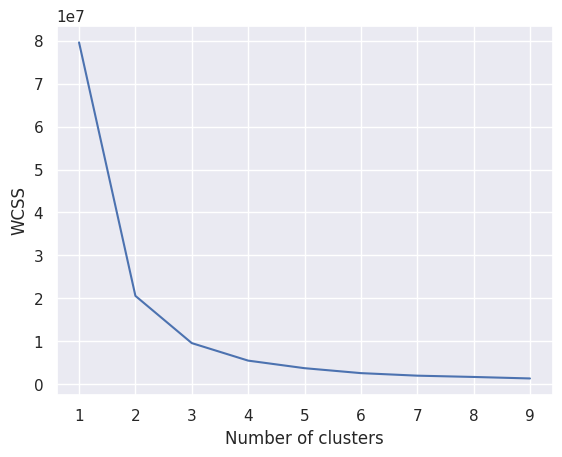

In [228]:
plt.plot(range(1,10),wcss)

# Name your axes
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [247]:
outlier_percent = []
for eps in np.linspace(0.01,4,100):

    # Create Model
    dbscan = DBSCAN(eps=eps,min_samples=2*len(x_scaled.columns))
    dbscan.fit(x_scaled)


    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)

    outlier_percent.append(perc_outliers)

Text(0.5, 0, 'Epsilon Value')

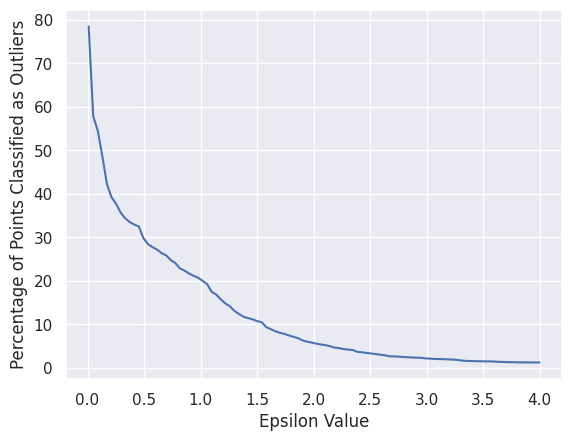

In [248]:
sns.lineplot(x=np.linspace(0.01,4,100),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

In [98]:
x_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4631 entries, 1 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   status_type    4631 non-null   float64
 1   num_reactions  4631 non-null   float64
 2   num_comments   4631 non-null   float64
 3   num_shares     4631 non-null   float64
 4   num_likes      4631 non-null   float64
 5   num_loves      4631 non-null   float64
 6   num_wows       4631 non-null   float64
 7   num_hahas      4631 non-null   float64
 8   num_sads       4631 non-null   float64
 9   num_angrys     4631 non-null   float64
dtypes: float64(10)
memory usage: 398.0 KB


<Axes: xlabel='num_reactions', ylabel='num_shares'>

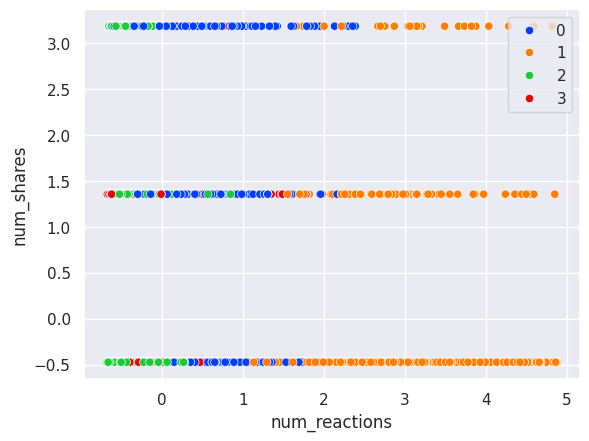

In [261]:
sns.scatterplot(data=x_scaled,x='num_reactions',y='num_shares',hue=y_pred_KM,palette='bright')

<Axes: xlabel='num_reactions', ylabel='num_shares'>

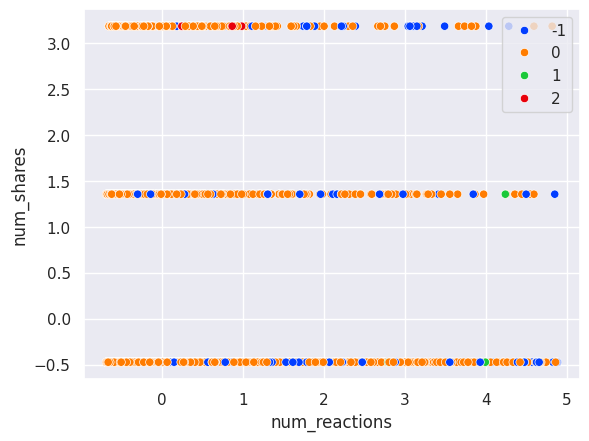

In [299]:
sns.scatterplot(data=x_scaled,x='num_reactions',y='num_shares',hue=y_pred_db,palette='bright')

<Axes: xlabel='status_type', ylabel='num_reactions'>

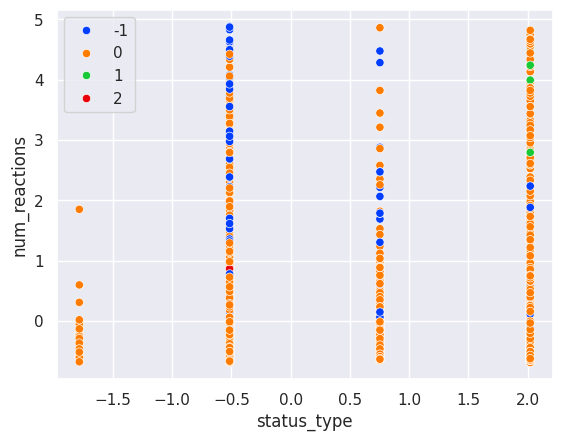

In [300]:
sns.scatterplot(data=x_scaled,x='status_type',y='num_reactions',hue=y_pred_db,palette='bright')

<Axes: xlabel='status_type', ylabel='num_reactions'>

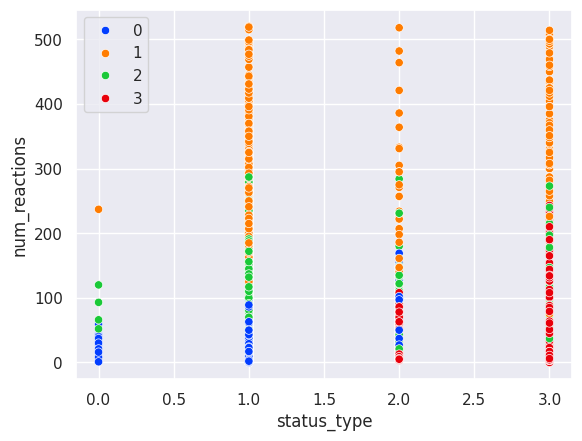

In [301]:
sns.scatterplot(data=data_cp,x='status_type',y='num_reactions',hue=y_pred_KM,palette='bright')

<Axes: xlabel='num_wows', ylabel='num_loves'>

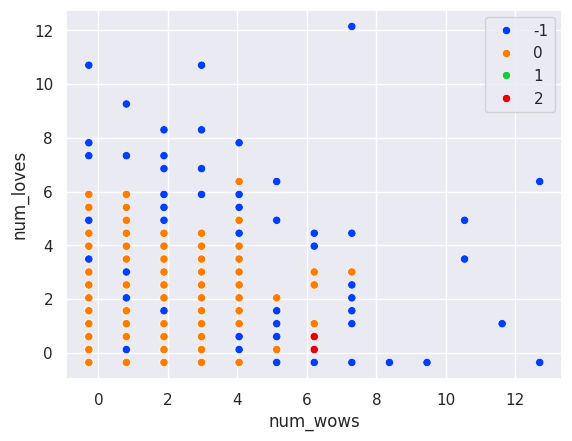

In [303]:
sns.scatterplot(data=x_scaled,x='num_wows',y='num_loves',hue=y_pred_db,palette='bright')

In [176]:
from sklearn.metrics import silhouette_score

In [284]:
print('silhouette_score of DBSCAN= ',silhouette_score(x_scaled,y_pred_db))

silhouette_score of DBSCAN=  0.539612295408703


In [285]:
print('silhouette_score of KMeans= ',silhouette_score(x_scaled,y_pred_KM))

silhouette_score of KMeans=  0.4086629989541174


Using PCA

In [179]:
from sklearn.decomposition import PCA

In [286]:
pca = PCA(n_components=2)
pca.fit(x_scaled.drop('status_type',axis=1))

PCA(n_components=2)

In [287]:
x_pca = pca.transform(x_scaled.drop('status_type',axis=1).values)
x_pca

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


array([[ 0.42554156, -0.60665394],
       [-0.01665264, -0.44242102],
       [ 2.87058465, -1.33891032],
       ...,
       [-0.7907498 ,  0.60469743],
       [-1.06022547, -0.03529518],
       [-1.08245404, -0.04657757]])

In [288]:
x_pca = pd.DataFrame(x_pca, columns=["x", "y"])
x_pca

,x,y
0,0.425542,-0.606654
1,-0.016653,-0.442421
2,2.870585,-1.338910
3,2.829006,-0.727958
4,2.040915,-1.075170
...,...,...
4626,-0.300110,-0.337144
4627,-0.266096,-0.349777
4628,-0.790750,0.604697
4629,-1.060225,-0.035295


In [289]:
x_pca['status_type']=x_scaled['status_type'].values
x_pca

,x,y,status_type
0,0.425542,-0.606654,-0.514634
1,-0.016653,-0.442421,-0.514634
2,2.870585,-1.338910,-0.514634
3,2.829006,-0.727958,-0.514634
4,2.040915,-1.075170,-0.514634
...,...,...,...
4626,-0.300110,-0.337144,-0.514634
4627,-0.266096,-0.349777,-0.514634
4628,-0.790750,0.604697,-0.514634
4629,-1.060225,-0.035295,-0.514634


In [290]:
y_pred_db2=model_db.fit_predict(x_pca)
y_pred_KM2=model_KM.fit_predict(x_pca)

In [291]:
print('silhouette_score of DBSCAN= ',silhouette_score(x_pca,y_pred_db2))

silhouette_score of DBSCAN=  0.8673079340402943


In [292]:
print('silhouette_score of KMeans= ',silhouette_score(x_pca,y_pred_KM2))

silhouette_score of KMeans=  0.5018033194658243


**Supervised**

In [305]:
from sklearn.naive_bayes import GaussianNB,  BernoulliNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [306]:
x_scaled

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
1,-0.514634,0.921267,-0.634945,-0.471573,0.949634,-0.356663,-0.275502,-0.096654,-0.099157,-0.061336
3,-0.514634,0.503558,-0.634945,-0.471573,0.524836,-0.356663,-0.275502,-0.096654,-0.099157,-0.061336
4,-0.514634,1.596029,-0.634945,-0.471573,1.537817,3.970955,-0.275502,-0.096654,-0.099157,-0.061336
5,-0.514634,1.638871,0.285666,-0.471573,1.614063,2.047569,0.805725,-0.096654,-0.099157,-0.061336
8,-0.514634,1.488924,-0.481510,-0.471573,1.472464,2.047569,-0.275502,-0.096654,-0.099157,-0.061336
...,...,...,...,...,...,...,...,...,...,...
7044,-0.514634,0.235795,-0.634945,-0.471573,0.252529,-0.356663,-0.275502,-0.096654,-0.099157,-0.061336
7045,-0.514634,0.267927,-0.634945,-0.471573,0.285205,-0.356663,-0.275502,-0.096654,-0.099157,-0.061336
7046,-0.514634,-0.513940,-0.634945,-0.471573,-0.531715,0.124183,-0.275502,1.473896,-0.099157,-0.061336
7047,-0.514634,-0.663887,-0.634945,-0.471573,-0.673315,0.124183,-0.275502,-0.096654,-0.099157,-0.061336


In [462]:
x=x_scaled.drop(['status_type','num_reactions'],axis=1)
y=data_cp['status_type']
#y=x_scaled['status_type']

In [463]:
y=np.array(y)
x=np.array(x)
x

array([[-0.63494491, -0.47157306,  0.94963436, ..., -0.09665449,
        -0.09915702, -0.06133624],
       [-0.63494491, -0.47157306,  0.52483557, ..., -0.09665449,
        -0.09915702, -0.06133624],
       [-0.63494491, -0.47157306,  1.5378173 , ..., -0.09665449,
        -0.09915702, -0.06133624],
       ...,
       [-0.63494491, -0.47157306, -0.53171527, ...,  1.47389626,
        -0.09915702, -0.06133624],
       [-0.63494491, -0.47157306, -0.67331487, ..., -0.09665449,
        -0.09915702, -0.06133624],
       [-0.63494491, -0.47157306, -0.49903844, ..., -0.09665449,
        -0.09915702, -0.06133624]])

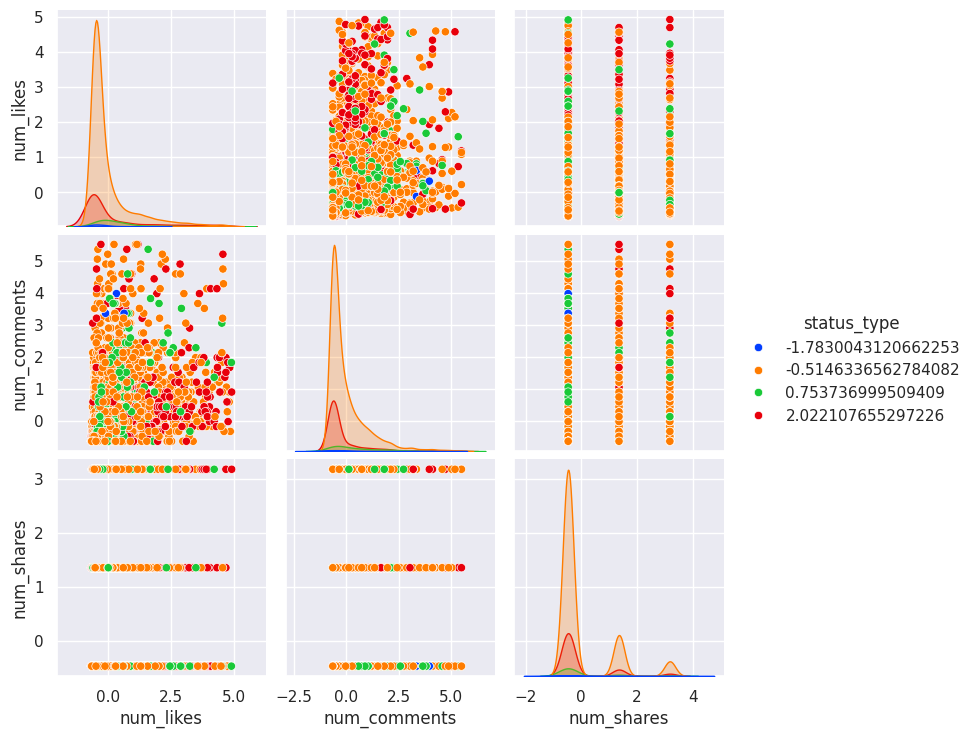

In [332]:
sns.pairplot(x_scaled , hue = 'status_type', vars = ['num_likes', 'num_comments','num_shares'], palette='bright' )

In [464]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)

In [465]:
model_nv = BernoulliNB()
model_nv.fit(x_train, y_train)
y_pred_nv = model_nv.predict(x_test)

In [466]:
svc_model = SVC(kernel='rbf')
svc_model.fit(x_train, y_train)

SVC()

In [467]:
y_pred_svm = svc_model.predict(x_test)

In [468]:
print("accuracy score of BernoulliNB= ",accuracy_score(y_test,y_pred_nv))

accuracy score of BernoulliNB=  0.7669064748201438


In [469]:
print("accuracy score of SVM= ",accuracy_score(y_test,y_pred_svm))

accuracy score of SVM=  0.7798561151079136


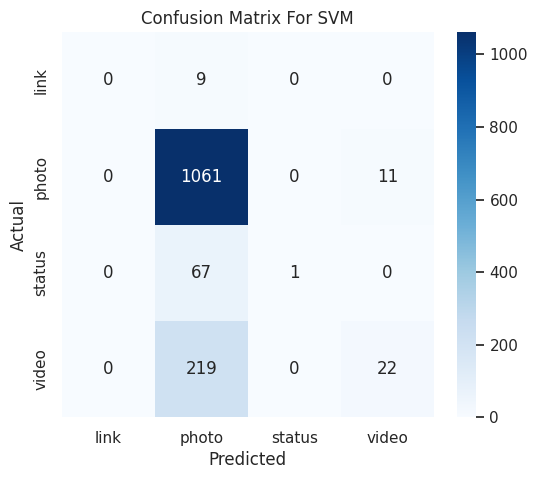

In [449]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d',
            xticklabels=["link", "photo","status","video"],
            yticklabels=["link", "photo","status","video"], cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix For SVM")
plt.show()

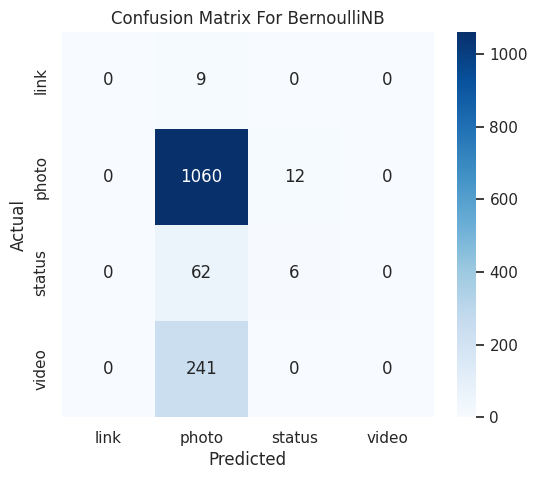

In [386]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_nv), annot=True, fmt='d',
            xticklabels=["link", "photo","status","video"],
            yticklabels=["link", "photo","status","video"], cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix For BernoulliNB")
plt.show()

In [407]:
from sklearn.ensemble import RandomForestClassifier

In [450]:
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)

rf_clf.fit(x_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [451]:
y_pred = rf_clf.predict(x_test)

In [460]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Random Forest Classifier Accuracy: {accuracy:}")

Random Forest Classifier Accuracy: 0.7906474820143885


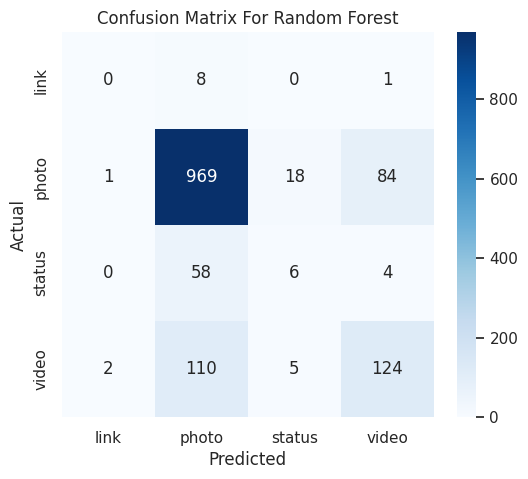

In [431]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=["link", "photo","status","video"],
            yticklabels=["link", "photo","status","video"], cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix For Random Forest")
plt.show()

**using x_pca**

In [453]:
x2=x_pca.drop(['status_type'],axis=1)
y2=data_cp['status_type']

In [454]:
x_train, x_test, y_train, y_test = train_test_split(x2, y2, test_size = 0.3, random_state=42)

In [455]:
svc_model = SVC(kernel='rbf')
svc_model.fit(x_train, y_train)

SVC()

In [456]:
y_pred_svm = svc_model.predict(x_test)

In [457]:
print("accuracy score of SVM= ",accuracy_score(y_test,y_pred_svm))

accuracy score of SVM=  0.7712230215827338


In [458]:
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)

rf_clf.fit(x_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [459]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Random Forest Classifier Accuracy: {accuracy:}")

Random Forest Classifier Accuracy: 0.7906474820143885
